# Module 16: XVA & Counterparty Credit Risk

This notebook verifies the implementation of the XVA mathematical models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from xva.exposure import simulate_exposures
from xva.xva import calculate_cva, calculate_dva, calculate_fva, calculate_cva_wwr, calculate_kva

np.random.seed(42)

## 1. Exposure Simulation

Simulate Mark-to-Market (MtM) paths and calculate EE, PFE (95%), and ENE.

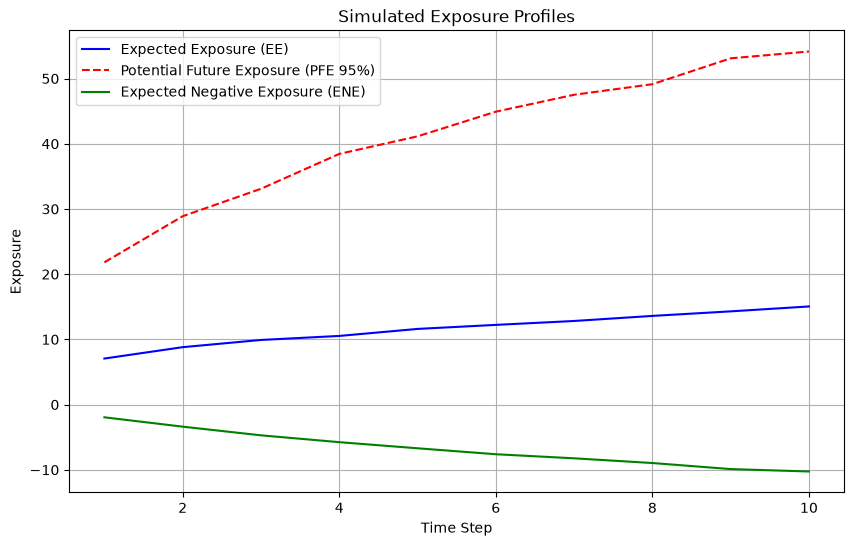

In [2]:
num_paths = 1000
num_steps = 10

# Simulate Brownian motion for MtM
dt = 1.0
dw = np.random.normal(0, np.sqrt(dt), (num_paths, num_steps))
mtm_paths = np.cumsum(dw, axis=1) * 10 + 5.0  # drift and scale

ee, pfe, ene = simulate_exposures(mtm_paths)

time_grid = np.arange(1, num_steps + 1)

plt.figure(figsize=(10, 6))
plt.plot(time_grid, ee, label="Expected Exposure (EE)", color="blue")
plt.plot(
    time_grid,
    pfe,
    label="Potential Future Exposure (PFE 95%)",
    color="red",
    linestyle="--",
)
plt.plot(time_grid, ene, label="Expected Negative Exposure (ENE)", color="green")
plt.title("Simulated Exposure Profiles")
plt.xlabel("Time Step")
plt.ylabel("Exposure")
plt.legend()
plt.grid(True)
plt.show()

## 2. Value Adjustments (XVA)

Calculate CVA, DVA, and FVA using the simulated exposures.

In [3]:
# Assumptions
pd = np.full(num_steps, 0.02)  # Marginal PD of counterparty
pd_own = np.full(num_steps, 0.015)  # Marginal PD of own firm
lgd = 0.6
lgd_own = 0.6
df = np.exp(-0.02 * time_grid)  # Discount factors
fca_spread = 0.015
fba_spread = 0.010

cva = calculate_cva(ee, pd, lgd, df)
dva = calculate_dva(ene, pd_own, lgd_own, df)
fva = calculate_fva(ee, ene, fca_spread, fba_spread, df, dt=dt)

print(f"Credit Valuation Adjustment (CVA): {cva:.2f}")
print(f"Debt Valuation Adjustment (DVA): {dva:.2f}")
print(f"Funding Valuation Adjustment (FVA): {fva:.2f}")

Credit Valuation Adjustment (CVA): 1.23
Debt Valuation Adjustment (DVA): 0.53
Funding Valuation Adjustment (FVA): 0.95


## 3. Margin Period of Risk (MPoR) & Initial Margin (IM)

Simulate collateralized exposures factoring in Variation Margin (VM) with a delay (MPoR) and Initial Margin.

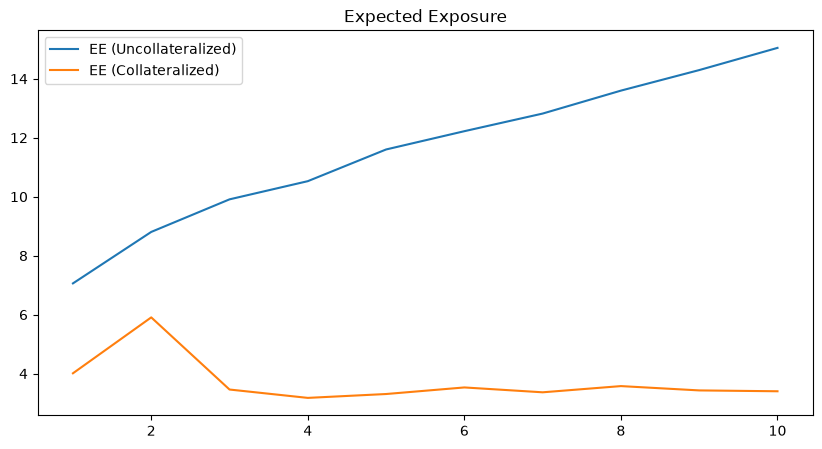

In [4]:
im_paths = np.full((num_paths, num_steps), 5.0)
mpor_steps = 2
ee_col, pfe_col, ene_col = simulate_exposures(mtm_paths, mpor_steps=mpor_steps, im_paths=im_paths)

plt.figure(figsize=(10, 5))
plt.plot(time_grid, ee, label="EE (Uncollateralized)")
plt.plot(time_grid, ee_col, label="EE (Collateralized)")
plt.title("Expected Exposure")
plt.legend()
plt.show()


## 4. Wrong-Way Risk (WWR)

Calculate CVA with Wrong-Way Risk (WWR) using a Gaussian copula to model correlation between exposure and probability of default.

In [5]:
correlation = 0.5  # Positive correlation indicates WWR
positive_exposures = np.maximum(mtm_paths, 0)

cva_no_wwr = calculate_cva_wwr(positive_exposures, pd, lgd, df, 0.0)
cva_wwr = calculate_cva_wwr(positive_exposures, pd, lgd, df, correlation)

print(f"CVA (No WWR): {cva_no_wwr:.4f}")
print(f"CVA (WWR): {cva_wwr:.4f}")


CVA (No WWR): 1.2332
CVA (WWR): 3.3590


## 5. KVA & Funding Asymmetry

Calculate Capital Valuation Adjustment (KVA) and Funding Valuation Adjustment (FVA) with asymmetric spreads.

In [6]:
# Asymmetric funding spreads over time
fca_spread_asym = np.linspace(0.015, 0.020, num_steps)
fba_spread_asym = np.linspace(0.010, 0.012, num_steps)

fva_asym = calculate_fva(ee, ene, fca_spread_asym, fba_spread_asym, df, dt)
print(f"FVA (Asymmetric): {fva_asym:.4f}")

# Capital Paths for KVA
capital_paths = np.linspace(50.0, 10.0, num_steps)  # declining capital
cost_of_capital = 0.10

kva = calculate_kva(capital_paths, cost_of_capital, df, dt)
print(f"KVA: {kva:.4f}")


FVA (Asymmetric): 1.1590
KVA: 27.5770
